In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)


In [2]:
df = pd.read_csv("netflix_titles.csv")
print("Shape:", df.shape)
display(df.head())
print(df.dtypes)


Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshab...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her si..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert ...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into ..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student a..."


show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [3]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
display(missing)

print("Type counts:")
display(df["type"].value_counts())

print("Unique ratings:")
display(df["rating"].value_counts(dropna=False).head(15))


,missing_values
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


Type counts:


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Unique ratings:


rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
Name: count, dtype: int64

In [4]:
movies = df[df["type"] == "Movie"].copy()
print("Movies only shape:", movies.shape)
display(movies.head())


Movies only shape: (6131, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, Sofia Carson, Liza Koshy, Ken Jeong, Elizabeth Perkins, Jane Krakowski...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,"Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegasi and Unicorns should be pals — and, hoof to..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra Duah, Nick Medley, Mutabaruka, Afemo Omilami, Reggie Carter, Mzuri","United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness ..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, Timothy Olyphant, Daveed Diggs, Skyler Gisondo, Laura Harrier, Rosalind...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contends with a feisty bird that's taken over her garden — and a husband who'...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, Edin Hasanović, Anna Fialová, Marlon Boess, Victor Boccard, Fleur Geff...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies","After most of her family is murdered in a terrorist bombing, a young woman is unknowingly lured into joining the ver..."


In [5]:
# Keep the fields needed for clustering
movies = movies[["title", "release_year", "rating", "duration", "listed_in", "description"]].copy()

# Drop rows missing the few fields we need
movies = movies.dropna(subset=["rating", "duration"]).copy()

# Parse duration from strings like '90 min'
movies["duration_minutes"] = movies["duration"].str.extract(r"(\d+)").astype(float)
movies = movies.dropna(subset=["duration_minutes"]).copy()

# Split genre strings into lists
movies["genre_list"] = movies["listed_in"].str.split(",").apply(lambda x: [g.strip() for g in x])

# Simplify ratings so the model is not dominated by many small categories
top_ratings = movies["rating"].value_counts().head(6).index
movies["rating_simplified"] = movies["rating"].where(movies["rating"].isin(top_ratings), "Other")

print("Cleaned movie shape:", movies.shape)
display(movies.head())


Cleaned movie shape: (6126, 9)


,title,release_year,rating,duration,listed_in,description,duration_minutes,genre_list,rating_simplified
0,Dick Johnson Is Dead,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to...",90.0,[Documentaries],PG-13
6,My Little Pony: A New Generation,2021,PG,91 min,Children & Family Movies,"Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegasi and Unicorns should be pals — and, hoof to...",91.0,[Children & Family Movies],PG
7,Sankofa,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness ...",125.0,"[Dramas, Independent Movies, International Movies]",TV-MA
9,The Starling,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contends with a feisty bird that's taken over her garden — and a husband who'...,104.0,"[Comedies, Dramas]",PG-13
12,Je Suis Karl,2021,TV-MA,127 min,"Dramas, International Movies","After most of her family is murdered in a terrorist bombing, a young woman is unknowingly lured into joining the ver...",127.0,"[Dramas, International Movies]",TV-MA


In [6]:
# One-hot encode genres
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies["genre_list"])
genre_df = pd.DataFrame(
    genre_matrix,
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=movies.index
)

# One-hot encode simplified ratings
rating_df = pd.get_dummies(movies["rating_simplified"], prefix="rating")

# Scale numeric fields
scaler = StandardScaler()
numeric_scaled = pd.DataFrame(
    scaler.fit_transform(movies[["release_year", "duration_minutes"]]),
    columns=["release_year_scaled", "duration_minutes_scaled"],
    index=movies.index
)

# Combine everything
X = pd.concat([genre_df, rating_df, numeric_scaled], axis=1)

print("Feature matrix shape:", X.shape)
display(X.head())


Feature matrix shape: (6126, 29)


,genre_Action & Adventure,genre_Anime Features,genre_Children & Family Movies,genre_Classic Movies,genre_Comedies,genre_Cult Movies,genre_Documentaries,genre_Dramas,genre_Faith & Spirituality,genre_Horror Movies,genre_Independent Movies,genre_International Movies,genre_LGBTQ Movies,genre_Movies,genre_Music & Musicals,genre_Romantic Movies,genre_Sci-Fi & Fantasy,genre_Sports Movies,genre_Stand-Up Comedy,genre_Thrillers,rating_Other,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-MA,rating_TV-PG,release_year_scaled,duration_minutes_scaled
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True,False,False,False,False,0.710660,-0.338917
6,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,False,False,0.813956,-0.303557
7,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,False,False,False,False,False,True,False,-2.078327,0.898667
9,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True,False,False,False,False,0.813956,0.156116
12,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,False,False,False,False,False,True,False,0.813956,0.969386


In [7]:
# Optional: use a sample for faster silhouette scoring if needed
sample_n = min(2000, len(X))
X_eval = X.sample(sample_n, random_state=42) if len(X) > sample_n else X.copy()

k_values = list(range(3, 9))
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_eval)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_eval, labels))

results_df = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette_score": silhouettes
})

display(results_df)


,k,inertia,silhouette_score
0,3,6213.619207,0.158776
1,4,5765.827130,0.122803
2,5,5395.050659,0.137478
3,6,5110.932277,0.127343
4,7,4874.607504,0.134624
5,8,4687.750105,0.146748


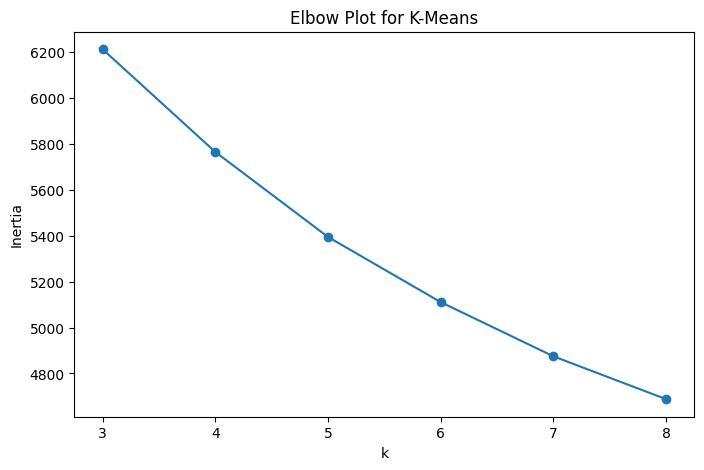

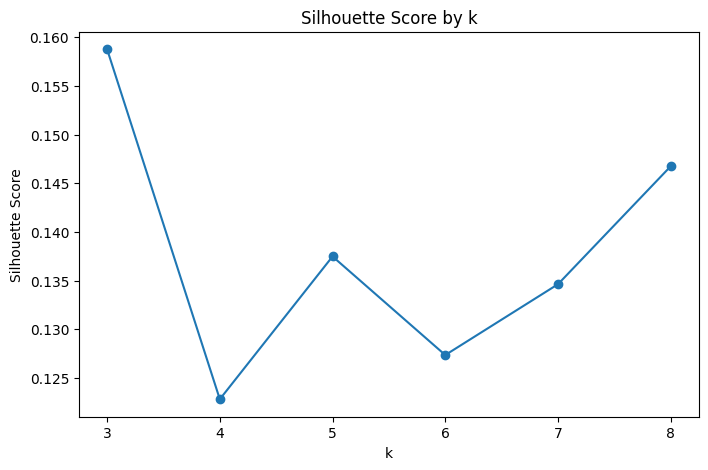

In [8]:
plt.plot(results_df["k"], results_df["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-Means")
plt.show()

plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.show()


In [9]:
final_k = 5  # Change this if your elbow/silhouette results suggest a better value

final_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
movies["cluster"] = final_model.fit_predict(X)

movies[["title", "cluster"]].head()


,title,cluster
0,Dick Johnson Is Dead,2
6,My Little Pony: A New Generation,2
7,Sankofa,3
9,The Starling,2
12,Je Suis Karl,4


In [10]:
cluster_sizes = movies["cluster"].value_counts().sort_index().to_frame("cluster_size")
display(cluster_sizes)


,cluster_size
cluster,
0,1183
1,1008
2,1649
3,414
4,1872


In [11]:
summary_rows = []

genre_columns = genre_df.columns.tolist()
rating_columns = rating_df.columns.tolist()

feature_with_cluster = X.copy()
feature_with_cluster["cluster"] = movies["cluster"]

for c in sorted(movies["cluster"].unique()):
    subset = movies[movies["cluster"] == c]
    x_subset = feature_with_cluster[feature_with_cluster["cluster"] == c]

    top_genres = (
        x_subset[genre_columns]
        .mean()
        .sort_values(ascending=False)
        .head(5)
        .index
        .str.replace("genre_", "", regex=False)
        .tolist()
    )

    top_ratings_cluster = (
        subset["rating_simplified"]
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    example_titles = subset["title"].head(5).tolist()

    summary_rows.append({
        "cluster": c,
        "size": len(subset),
        "avg_release_year": round(subset["release_year"].mean(), 1),
        "avg_duration_minutes": round(subset["duration_minutes"].mean(), 1),
        "top_genres": ", ".join(top_genres),
        "top_ratings": ", ".join(top_ratings_cluster),
        "example_titles": "; ".join(example_titles)
    })

cluster_summary = pd.DataFrame(summary_rows).sort_values("cluster")
display(cluster_summary)


,cluster,size,avg_release_year,avg_duration_minutes,top_genres,top_ratings,example_titles
0,0,1183,2013.5,132.5,"International Movies, Dramas, Comedies, Action & Adventure, Romantic Movies","TV-14, TV-MA, TV-PG",Jeans; Minsara Kanavu; Ankahi Kahaniya; Naruto Shippuden the Movie: Blood Prison; King of Boys
1,1,1008,2016.5,58.0,"Documentaries, Stand-Up Comedy, Children & Family Movies, International Movies, Comedies","TV-MA, Other, TV-14",Europe's Most Dangerous Man: Otto Skorzeny in Spain; Go! Go! Cory Carson: Chrissy Takes the Wheel; My Heroes Were Co...
2,2,1649,2013.7,99.4,"Comedies, Dramas, Action & Adventure, Children & Family Movies, Independent Movies","R, PG-13, PG",Dick Johnson Is Dead; My Little Pony: A New Generation; The Starling; Confessions of an Invisible Girl; Intrusion
3,3,414,1984.2,115.2,"Dramas, International Movies, Action & Adventure, Comedies, Classic Movies","TV-14, R, PG-13",Sankofa; Avvai Shanmughi; Jaws; Jaws 2; Jaws 3
4,4,1872,2017.0,97.9,"International Movies, Dramas, Comedies, Independent Movies, Documentaries","TV-MA, TV-14, TV-PG",Je Suis Karl; The Father Who Moves Mountains; The Stronghold; Schumacher; Prey


In [12]:
for c in sorted(movies["cluster"].unique()):
    print(f"\nCluster {c}")
    display(
        movies.loc[movies["cluster"] == c, ["title", "listed_in", "rating", "release_year", "duration_minutes", "description"]]
        .head(8)
    )



Cluster 0


,title,listed_in,rating,release_year,duration_minutes,description
24,Jeans,"Comedies, International Movies, Romantic Movies",TV-14,1998,166.0,"When the father of the man she loves insists that his twin sons marry twin sisters, a woman creates an alter ego tha..."
26,Minsara Kanavu,"Comedies, International Movies, Music & Musicals",TV-PG,1997,147.0,A tangled love triangle ensues when a man falls for a woman studying to become a nun — and she falls for the friend ...
30,Ankahi Kahaniya,"Dramas, Independent Movies, International Movies",TV-14,2021,111.0,"As big city life buzzes around them, lonely souls discover surprising sources of connection and companionship in thr..."
56,Naruto Shippuden the Movie: Blood Prison,"Action & Adventure, Anime Features, International Movies",TV-14,2011,102.0,"Mistakenly accused of an attack on the Fourth Raikage, ninja Naruto is imprisoned in the impenetrable Hozuki Castle ..."
73,King of Boys,"Dramas, International Movies",TV-MA,2018,182.0,"When a powerful businesswoman’s political ambitions are threatened by her underworld connections, the ensuing power ..."
78,Tughlaq Durbar,"Comedies, Dramas, International Movies",TV-14,2020,145.0,A budding politician has devious plans to rise in the ranks — until an unexpected new presence begins to interfere w...
79,Tughlaq Durbar (Telugu),"Comedies, Dramas, International Movies",TV-14,2021,145.0,A budding politician has devious plans to rise in the ranks — until an unexpected new presence begins to interfere w...
84,Omo Ghetto: the Saga,"Action & Adventure, Comedies, Dramas",TV-MA,2020,147.0,"Twins are reunited as a good-hearted female gangster and her uptight rich sister take on family, crime, cops and all..."



Cluster 1


,title,listed_in,rating,release_year,duration_minutes,description
16,Europe's Most Dangerous Man: Otto Skorzeny in Spain,"Documentaries, International Movies",TV-MA,2020,67.0,"Declassified documents reveal the post-WWII life of Otto Skorzeny, a close Hitler ally who escaped to Spain and beca..."
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,Children & Family Movies,TV-Y,2021,61.0,"From arcade games to sled days and hiccup cures, Cory Carson’s curious little sister Chrissy speeds off on her own f..."
45,My Heroes Were Cowboys,Documentaries,PG,2021,23.0,"Robin Wiltshire's painful childhood was rescued by Westerns. Now he lives on the frontier of his dreams, training th..."
71,A StoryBots Space Adventure,Children & Family Movies,TV-Y,2021,13.0,Join the StoryBots and the space travelers of the historic Inspiration4 mission as they search for answers to kids' ...
77,Little Singham - Black Shadow,"Children & Family Movies, Comedies",TV-Y7,2021,48.0,Kid cop Little Singham loses all his superpowers while trying to stop the demon Kaal’s new evil plans! Can his inner...
101,Untold: Breaking Point,"Documentaries, Sports Movies",TV-MA,2021,80.0,"Under pressure to continue a winning tradition in American tennis, Mardy Fish faced mental health challenges that ch..."
130,Barbie Big City Big Dreams,"Children & Family Movies, Music & Musicals",TV-Y,2021,63.0,"At a summer performing arts program in New York City, Barbie from Malibu meets Barbie from Brooklyn, and the two bec..."
233,Count Me In,"Documentaries, Music & Musicals",TV-MA,2021,82.0,This documentary features some of rock's greatest drummers as they come together in an inspiring rhythmic journey ab...



Cluster 2


,title,listed_in,rating,release_year,duration_minutes,description
0,Dick Johnson Is Dead,Documentaries,PG-13,2020,90.0,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to..."
6,My Little Pony: A New Generation,Children & Family Movies,PG,2021,91.0,"Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegasi and Unicorns should be pals — and, hoof to..."
9,The Starling,"Comedies, Dramas",PG-13,2021,104.0,A woman adjusting to life after a loss contends with a feisty bird that's taken over her garden — and a husband who'...
13,Confessions of an Invisible Girl,"Children & Family Movies, Comedies",TV-PG,2021,91.0,"When the clever but socially-awkward Tetê joins a new school, she'll do anything to fit in. But the queen bee among ..."
18,Intrusion,Thrillers,TV-14,2021,94.0,"After a deadly home invasion at a couple’s new dream house, the traumatized wife searches for answers — and learns t..."
27,Grown Ups,Comedies,PG-13,2010,103.0,"Mourning the loss of their beloved junior high basketball coach, five middle-aged pals reunite at a lake house and r..."
28,Dark Skies,"Horror Movies, Sci-Fi & Fantasy",PG-13,2013,97.0,"A family’s idyllic suburban life shatters when an alien force invades their home, and as they struggle to convince o..."
29,Paranoia,Thrillers,PG-13,2013,106.0,"Blackmailed by his company's CEO, a low-level employee finds himself forced to spy on the boss's rival and former me..."



Cluster 3


,title,listed_in,rating,release_year,duration_minutes,description
7,Sankofa,"Dramas, Independent Movies, International Movies",TV-MA,1993,125.0,"On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness ..."
22,Avvai Shanmughi,"Comedies, International Movies",TV-PG,1996,161.0,"Newly divorced and denied visitation rights with his daughter, a doting father disguises himself as a gray-haired na..."
41,Jaws,"Action & Adventure, Classic Movies, Dramas",PG,1975,124.0,"When an insatiable great white shark terrorizes Amity Island, a police chief, an oceanographer and a grizzled shark ..."
42,Jaws 2,"Dramas, Horror Movies, Thrillers",PG,1978,116.0,"Four years after the last deadly shark attacks, police chief Martin Brody fights to protect Amity Island from anothe..."
43,Jaws 3,"Action & Adventure, Horror Movies, Thrillers",PG,1983,98.0,"After the staff of a marine theme park try to capture a young great white shark, they discover its mother has invade..."
44,Jaws: The Revenge,"Action & Adventure, Horror Movies, Thrillers",PG-13,1987,91.0,"After another deadly shark attack, Ellen Brody has had enough of Amity Island and moves to the Caribbean – but a gre..."
114,Anjaam,"Dramas, International Movies, Thrillers",TV-14,1994,143.0,"A wealthy industrialist’s dangerous obsession with a flight attendant destroys her world, until she takes matters in..."
131,Blade Runner: The Final Cut,"Action & Adventure, Classic Movies, Cult Movies",R,1982,117.0,"In a smog-choked dystopian Los Angeles, blade runner Rick Deckard is called out of retirement to snuff a quartet of ..."



Cluster 4


,title,listed_in,rating,release_year,duration_minutes,description
12,Je Suis Karl,"Dramas, International Movies",TV-MA,2021,127.0,"After most of her family is murdered in a terrorist bombing, a young woman is unknowingly lured into joining the ver..."
35,The Father Who Moves Mountains,"Dramas, International Movies, Thrillers",TV-MA,2021,110.0,"When his son goes missing during a snowy hike in the mountains, a retired intelligence officer will stop at nothing ..."
36,The Stronghold,"Action & Adventure, Dramas, International Movies",TV-MA,2021,105.0,"Tired of the small-time grind, three Marseille cops get a chance to bust a major drug network. But lines blur when a..."
68,Schumacher,"Documentaries, International Movies, Sports Movies",TV-14,2021,113.0,"Through exclusive interviews and archival footage, this documentary traces an intimate portrait of seven-time Formul..."
86,Prey,"International Movies, Thrillers",TV-MA,2021,87.0,A hiking trip into the wild turns into a desperate bid for survival for five friends on the run from a mysterious sh...
90,Paradise Hills,"Sci-Fi & Fantasy, Thrillers",TV-MA,2019,95.0,"Uma wakes up in a lush tropical facility designed to turn willful girls into perfect ladies. That’s bad enough, but ..."
91,The Women and the Murderer,"Documentaries, International Movies",TV-14,2021,92.0,This documentary traces the capture of serial killer Guy Georges through the tireless work of two women: a police ch...
93,JJ+E,"Dramas, International Movies, Romantic Movies",TV-MA,2021,91.0,"Elisabeth and John-John live in the same city, but they inhabit different worlds. Can a passionate first love break ..."


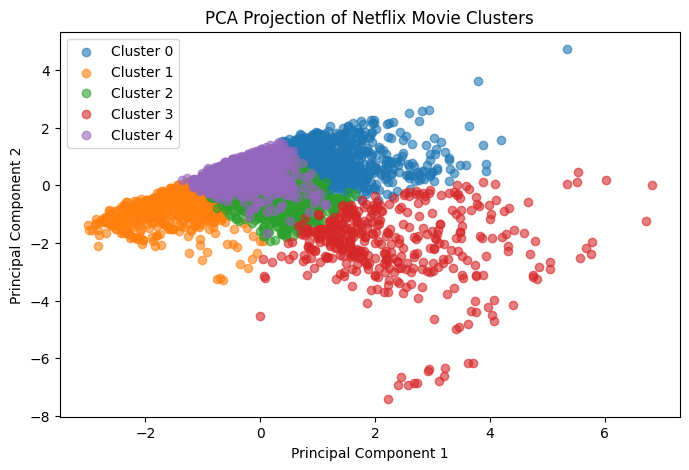

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster": movies["cluster"].values
})

for c in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == c]
    plt.scatter(subset["pc1"], subset["pc2"], label=f"Cluster {c}", alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Netflix Movie Clusters")
plt.legend()
plt.show()
